1. Chargement et filtrage STRICT sur Paris (75)...
2. Fusion et Création des variables...

3. Statistiques du jeu de données...
--------------------------------------------------
Nombre total de jours analysés : 184
Trafic moyen journalier        : 2,233,494 voyageurs
Trafic maximum (pic)           : 3,743,515 voyageurs
Trafic minimum (creux)         : 171,281 voyageurs
Nombre de jours de grève       : 27 jours
Nombre de jours fériés         : 5 jours
--------------------------------------------------

4. Préparation pour l'IA...
L'IA va s'entraîner sur 147 jours (Uniquement Paris).

5. Entraînement en cours (Random Forest)...

RESULTATS DU MODELE CORRIGE :
- Marge d'erreur absolue : 157999 voyageurs / jour
- Marge d'erreur relative: 10.3%
- Score R2               : 0.93 / 1.00


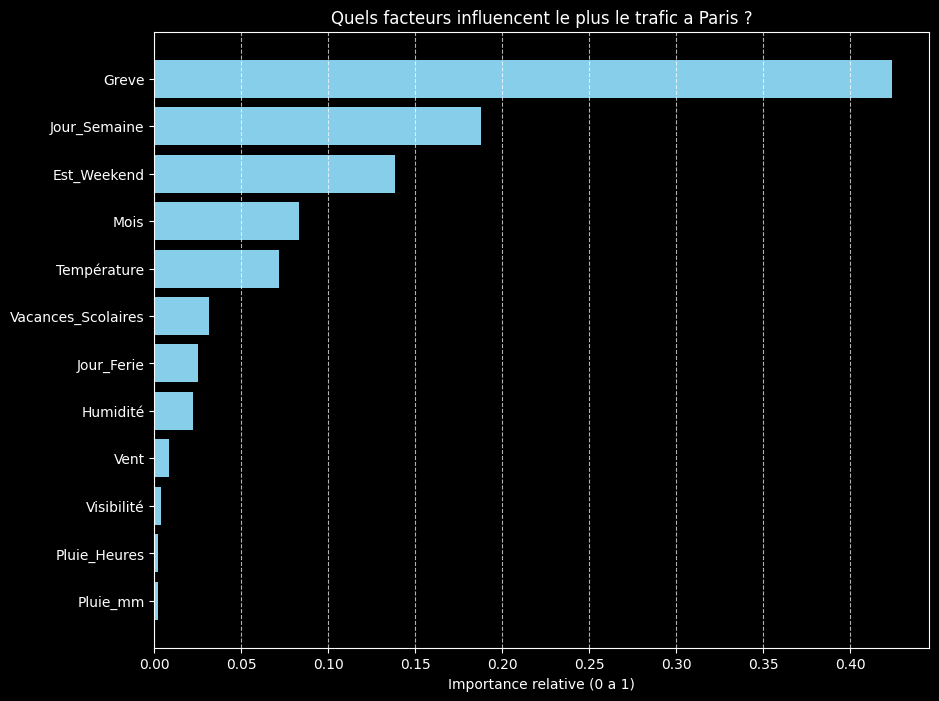


SIMULATEUR D'AFFLUENCE RATP (PARIS 75)
Lundi de Novembre (Normal)             : 3,331,983 voyageurs
Lundi de Novembre (Ferie - ex: 11 nov) : 2,046,399 voyageurs
Lundi de Novembre (Vacances Scolaires) : 3,157,238 voyageurs
Lundi de Novembre (Greve)              : 748,108 voyageurs
--------------------------------------------------
IMPACTS CALCULES PAR L'IA :
  - Un jour ferie fait chuter le trafic de 38.6%
  - Les vacances font chuter le trafic de 5.2%
  - La greve fait chuter le trafic de 77.5%


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

print("1. Chargement et filtrage STRICT sur Paris (75)...")
# Chargement des données
df_transports = pd.read_csv('Travel_titles_with_departments.csv')
df_meteo = pd.read_csv('meteo_juillet_decembre_2019.csv')

# Filtre sur le département 75 (Paris)
df_transports = df_transports[df_transports['DEPARTEMENT'] == 75].copy()

# Remise au format Date
df_transports['DATE'] = pd.to_datetime(df_transports['DATE'])
if 'JOUR' in df_meteo.columns:
    df_meteo = df_meteo.rename(columns={'JOUR': 'DATE'})
df_meteo['DATE'] = pd.to_datetime(df_meteo['DATE'])

# Regroupement par jour pour être sûr d'avoir 1 ligne = 1 jour
df_transports = df_transports.groupby('DATE', as_index=False)['NB_VALID'].sum()

print("2. Fusion et Création des variables...")
df_ml = pd.merge(df_transports, df_meteo, on='DATE', how='inner')

# --- VARIABLES TEMPORELLES DE BASE ---
df_ml['Jour_Semaine'] = df_ml['DATE'].dt.dayofweek
df_ml['Est_Weekend'] = df_ml['Jour_Semaine'].apply(lambda x: 1 if x >= 5 else 0)
df_ml['Mois'] = df_ml['DATE'].dt.month
df_ml['Greve'] = df_ml['DATE'].apply(lambda x: 1 if x >= pd.to_datetime('2019-12-05') else 0)

# --- JOURS FÉRIÉS (S2 2019) ---
jours_feries_2019 = pd.to_datetime([
    '2019-07-14', # Fête nationale
    '2019-08-15', # Assomption
    '2019-11-01', # Toussaint
    '2019-11-11', # Armistice
    '2019-12-25'  # Noël
])
df_ml['Jour_Ferie'] = df_ml['DATE'].isin(jours_feries_2019).astype(int)

# --- VACANCES SCOLAIRES (Zone C - S2 2019) ---
vacances_ete = pd.date_range(start='2019-07-01', end='2019-09-01')
vacances_toussaint = pd.date_range(start='2019-10-19', end='2019-11-03')
vacances_noel = pd.date_range(start='2019-12-21', end='2019-12-31')

toutes_vacances = vacances_ete.union(vacances_toussaint).union(vacances_noel)
df_ml['Vacances_Scolaires'] = df_ml['DATE'].isin(toutes_vacances).astype(int)

# --- NOUVEAU : STATISTIQUES DESCRIPTIVES ---
print("\n3. Statistiques du jeu de données...")
print("-" * 50)
print(f"Nombre total de jours analysés : {len(df_ml)}")
print(f"Trafic moyen journalier        : {int(df_ml['NB_VALID'].mean()):,} voyageurs")
print(f"Trafic maximum (pic)           : {int(df_ml['NB_VALID'].max()):,} voyageurs")
print(f"Trafic minimum (creux)         : {int(df_ml['NB_VALID'].min()):,} voyageurs")
print(f"Nombre de jours de grève       : {df_ml['Greve'].sum()} jours")
print(f"Nombre de jours fériés         : {df_ml['Jour_Ferie'].sum()} jours")
print("-" * 50)

print("\n4. Préparation pour l'IA...")
# Liste de toutes les colonnes utiles pour l'entraînement
colonnes_features = [
    'Température', 'Pluie_mm', 'Pluie_Heures', 'Humidité', 'Vent', 'Visibilité',
    'Jour_Semaine', 'Est_Weekend', 'Mois', 'Greve', 'Jour_Ferie', 'Vacances_Scolaires'
]

X = df_ml[colonnes_features]
y = df_ml['NB_VALID']

# On sépare les données (80% pour apprendre, 20% pour vérifier)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"L'IA va s'entraîner sur {len(X_train)} jours (Uniquement Paris).")

print("\n5. Entraînement en cours (Random Forest)...")
modele = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modele.fit(X_train, y_train)

# --- RÉSULTATS ---
predictions = modele.predict(X_test)
erreur_moyenne = mean_absolute_error(y_test, predictions)
pourcentage_erreur = mean_absolute_percentage_error(y_test, predictions) * 100
score_r2 = r2_score(y_test, predictions)

print("\nRESULTATS DU MODELE CORRIGE :")
print(f"- Marge d'erreur absolue : {erreur_moyenne:.0f} voyageurs / jour")
print(f"- Marge d'erreur relative: {pourcentage_erreur:.1f}%")
print(f"- Score R2               : {score_r2:.2f} / 1.00")

# --- GRAPHIQUE DES IMPORTANCES ---
importances = modele.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Quels facteurs influencent le plus le trafic a Paris ?')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [colonnes_features[i] for i in indices])
plt.xlabel('Importance relative (0 a 1)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show() # Affiche le graphique


# --- FONCTION DE SIMULATION ---
def calculer_affluence(modele_entraine, colonnes_entrainement, temp, pluie, greve, jour_ferie=0, vacances_scolaires=0, jour_type="Lundi", mois=12):
    jours = {"Lundi":0, "Mardi":1, "Mercredi":2, "Jeudi":3, "Vendredi":4, "Samedi":5, "Dimanche":6}

    jour_propre = jour_type.strip().capitalize()
    if jour_propre not in jours:
        raise ValueError(f"Erreur : Le jour '{jour_type}' n'est pas valide.")

    js = jours[jour_propre]
    weekend = 1 if js >= 5 else 0

    entree = pd.DataFrame([{
        'Température': temp,
        'Pluie_mm': pluie,
        'Pluie_Heures': 2 if pluie > 0 else 0,
        'Humidité': 80 if pluie > 0 else 50,
        'Vent': 15,
        'Visibilité': 15000,
        'Jour_Semaine': js,
        'Est_Weekend': weekend,
        'Mois': mois,
        'Greve': greve,
        'Jour_Ferie': jour_ferie,
        'Vacances_Scolaires': vacances_scolaires
    }])

    # On aligne l'ordre des colonnes avec celles de l'entraînement
    entree = entree[colonnes_entrainement]
    prediction = modele_entraine.predict(entree)[0]
    return int(prediction)

# --- SIMULATEUR ---
print("\n" + "="*50)
print("SIMULATEUR D'AFFLUENCE RATP (PARIS 75)")
print("="*50)

# Scénario Normal
s_normal = calculer_affluence(modele, colonnes_features, temp=10, pluie=0, greve=0, jour_ferie=0, vacances_scolaires=0, jour_type="Lundi", mois=11)
print(f"Lundi de Novembre (Normal)             : {s_normal:,} voyageurs")

# Scénario Férié
s_ferie = calculer_affluence(modele, colonnes_features, temp=10, pluie=0, greve=0, jour_ferie=1, vacances_scolaires=0, jour_type="Lundi", mois=11)
print(f"Lundi de Novembre (Ferie - ex: 11 nov) : {s_ferie:,} voyageurs")

# Scénario Vacances
s_vacances = calculer_affluence(modele, colonnes_features, temp=10, pluie=0, greve=0, jour_ferie=0, vacances_scolaires=1, jour_type="Lundi", mois=11)
print(f"Lundi de Novembre (Vacances Scolaires) : {s_vacances:,} voyageurs")

# Scénario Grève
s_greve = calculer_affluence(modele, colonnes_features, temp=10, pluie=0, greve=1, jour_ferie=0, vacances_scolaires=0, jour_type="Lundi", mois=11)
print(f"Lundi de Novembre (Greve)              : {s_greve:,} voyageurs")

print("-" * 50)

# Calculs des impacts
baisse_ferie = ((s_normal - s_ferie) / s_normal) * 100
baisse_vacances = ((s_normal - s_vacances) / s_normal) * 100
baisse_greve = ((s_normal - s_greve) / s_normal) * 100

print("IMPACTS CALCULES PAR L'IA :")
print(f"  - Un jour ferie fait chuter le trafic de {baisse_ferie:.1f}%")
print(f"  - Les vacances font chuter le trafic de {baisse_vacances:.1f}%")
print(f"  - La greve fait chuter le trafic de {baisse_greve:.1f}%")
print("="*50)